# Machine Learning: Overfitting and Underfitting

This notebook explores fundamental concepts in machine learning model evaluation, including overfitting, underfitting, and the bias-variance tradeoff.

## Learning Objectives
- Understand the concepts of overfitting and underfitting
- Visualize the relationship between model complexity and error
- Learn about the bias-variance tradeoff
- Identify optimal model complexity
- Understand cross-validation and regularization techniques

## Exercise 1: Understanding Overfitting

**Definition:** Overfitting occurs when a machine learning model learns the specific details and noise of the training data instead of learning general patterns. This results in excellent performance on training data but poor performance on new, unseen data.

**Characteristics:**
- Very low training error
- High test/validation error
- Model is too complex for the problem
- Does not generalize well to new data

**Causes:**
- Model is too complex
- Training dataset is too small
- Insufficient regularization
- Training for too many iterations

## Exercise 2: Visualizing Train vs Test Error

**Objective:** Create a visualization showing how train and test errors vary with model complexity.

**Key Concepts:**
- Model complexity increases from left to right
- Ideal model is at the intersection where test error is minimized
- Left side: Underfitting (both errors are high)
- Right side: Overfitting (train error is low, test error is high)

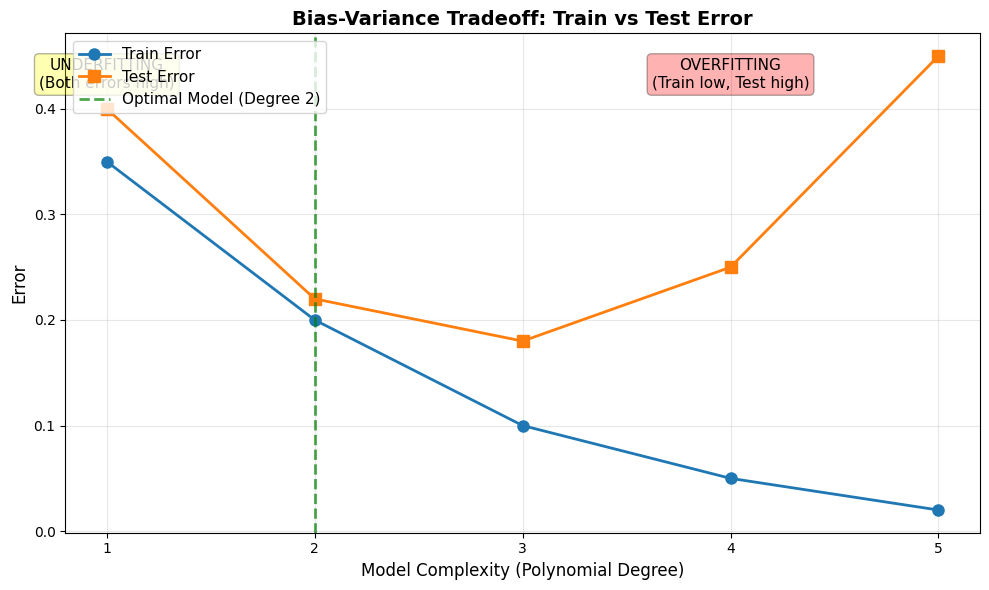

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Model complexity (polynomial degrees)
degrees = [1, 2, 3, 4, 5]

# Training and test errors
train_error = [0.35, 0.2, 0.1, 0.05, 0.02]
test_error = [0.40, 0.22, 0.18, 0.25, 0.45]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_error, marker='o', linewidth=2, markersize=8, 
         label='Train Error', color='#1f77b4')
plt.plot(degrees, test_error, marker='s', linewidth=2, markersize=8, 
         label='Test Error', color='#ff7f0e')

# Mark the optimal point
optimal_degree = 2
plt.axvline(x=optimal_degree, linestyle='--', color='green', linewidth=2, 
            label='Optimal Model (Degree 2)', alpha=0.7)

# Add annotations
plt.text(1.0, 0.42, 'UNDERFITTING\n(Both errors high)', fontsize=11, 
         ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
plt.text(4.0, 0.42, 'OVERFITTING\n(Train low, Test high)', fontsize=11, 
         ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# Labels and title
plt.title('Bias-Variance Tradeoff: Train vs Test Error', fontsize=14, fontweight='bold')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.xticks(degrees)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 3: Strategies to Combat Overfitting

**Common Techniques:**

1. **Regularization:**
   - L1 Regularization (Lasso): Adds penalty for large coefficients
   - L2 Regularization (Ridge): Shrinks coefficients proportionally
   - Elastic Net: Combination of L1 and L2

2. **Cross-Validation:**
   - K-Fold Cross-Validation: Splits data into k subsets
   - Stratified K-Fold: Maintains class distribution
   - Time Series Cross-Validation: Respects temporal order

3. **Data-Related Solutions:**
   - Increase training data size
   - Feature selection/engineering
   - Remove irrelevant features

4. **Model-Related Solutions:**
   - Use simpler models
   - Early stopping for neural networks
   - Reduce model complexity
   - Ensemble methods (bagging, boosting)

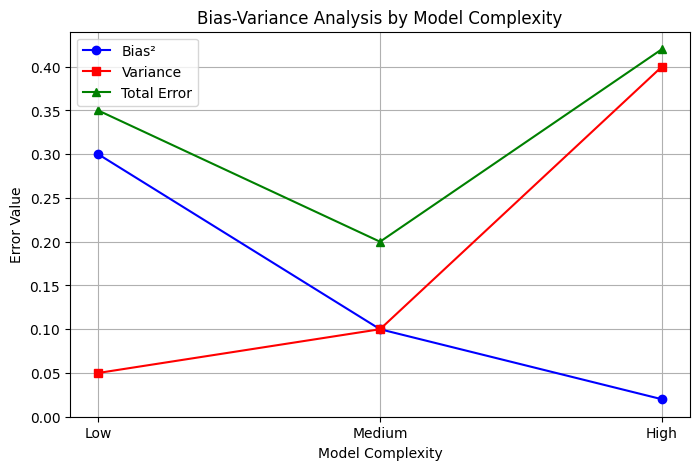

In [2]:
import matplotlib.pyplot as plt

complexity = ['Low', 'Medium', 'High']
bias_squared = [0.3, 0.1, 0.02]
variance = [0.05, 0.1, 0.4]

total_error = [b + v for b, v in zip(bias_squared, variance)]
# or

'''
total_error = []
for i in range(len(complexity)):
    total_error.append(bias_squared[i] + variance[i]) 
print(total_error)

'''

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias_squared, marker='o', label='Bias²', color='blue')
plt.plot(complexity, variance, marker='s', label='Variance', color='red')
plt.plot(complexity, total_error, marker='^', label='Total Error', color='green')

plt.title('Bias-Variance Analysis by Model Complexity')
plt.xlabel('Model Complexity')
plt.ylabel('Error Value')

plt.legend()
plt.grid(True)
plt.show()


---
---

# 4

 **Overfitting (Model A):**

- Large gap between training and test accuracy.

- The model is overfitting the training data and performs poorly on new, unseen data.

Overfitting → the model memorizes training examples and has poor generalization.

---

**Underfitting (Model C):**

- Low accuracy on both training and test sets → the model is too simple or under-trained.

Underfitting → the model has not learned the underlying patterns and shows low accuracy on both sets.

---

**Balanced Model (Model B):**

- Small gap between training and test accuracies.

- The model fits the data well and generalizes appropriately.

Balanced → training and test accuracies are close; the model achieves a good trade-off between fit and generalization.

---
---

# 5

## Computing Data Standardization

- **Mean:** The average value of the data
- **Standard Deviation:** A measure of how spread out the data are relative to the mean

---

**Standardization Formula:**

$$
Z = \frac{X - \mu}{\sigma}
$$

where:
- $X$ is the original data value
- $\mu$ is the mean of the data
- $\sigma$ is the standard deviation of the data

In [3]:
import numpy as np

# data
data = np.array([10, 20, 25])

# Calculate mean and standard deviation
mean = np.mean(data)
std = np.std(data)

print("Mean of the data:", mean)
print("Standard deviation of the data:", std)

# Standardize the data using Z-score
standardized = (data - mean) / std
print("Standardized values:", standardized)

# Check the range of standardized values
print("Minimum standardized value:", np.min(standardized))
print("Maximum standardized value:", np.max(standardized))


Mean of the data: 18.333333333333332
Standard deviation of the data: 6.236095644623236
Standardized values: [-1.33630621  0.26726124  1.06904497]
Minimum standardized value: -1.3363062095621216
Maximum standardized value: 1.0690449676496976


These values all fall approximately within the range [-2, +2].

This range in statistics represents normal behavior, meaning the data are not excessively outlying and their dispersion is acceptable.

---
---

# 6

## Data Normalization with Min-Max Scaling

**Normalization Formula**

To normalize data to the range [0, 1], we use the following formula:

$$
X_{\text{norm}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

---

In [4]:
import numpy as np

# Original data
data = np.array([5, 15, 25, 30])

# Compute minimum and maximum values
data_min = np.min(data)
data_max = np.max(data)

# Apply Min-Max normalization
normalized = (data - data_min) / (data_max - data_min)

# Display the results
print("Normalized data:", normalized)


Normalized data: [0.  0.4 0.8 1. ]


Normalization by placing data in a specific range like [0, 1] ensures all features are evaluated on the same scale, preventing features with larger numerical values from unfairly dominating the model. This input balance allows the model to learn general, generalizable patterns instead of focusing on random noise. As a result, normalization reduces unnecessary model complexity and prevents the model from excessively learning the training data, thereby reducing the risk of overfitting and improving generalization to unseen data.

---
---

# 7


###  Ridge Regression Weight Update (L2 Penalty)

**Model:** Ridge Regression
**Initial Weights:** $\mathbf{w}_{\text{old}} = [10, 5]$
**Regularization Parameter:** $\lambda = 1$
**Assumed Learning Rate:** $\eta = 0.01$

#### Calculation (Assuming $\nabla J_{\text{}} \approx 0$):

The Ridge update rule focuses on **weight shrinkage** using the factor $(1 - 2\eta\lambda)$:

$$
\mathbf{w}_{\text{new}} = (1 - 2\eta\lambda)\mathbf{w}_{\text{old}}
$$

$$
\mathbf{w}_{\text{new}} = (1 - 2 \cdot 0.01 \cdot 1) \cdot \begin{bmatrix} 10 \\ 5 \end{bmatrix} = 0.98 \cdot \begin{bmatrix} 10 \\ 5 \end{bmatrix}
$$

$$\mathbf{w}_{\text{new}} = \begin{bmatrix} 9.8 \\ 4.9 \end{bmatrix}$$

> **Result:** Both weights are shrunk towards zero, but neither is exactly zero.

---

In [5]:
import numpy as np

# Assumption: Learning Rate (eta) is assumed since it was not provided in the problem.
ASSUMED_ETA = 0.01 
# Note: Loss Gradient is assumed to be zero to isolate the penalty effect.

def calculate_ridge_regularized_weights(w_old, lambda_val, l1_ratio=None, eta=ASSUMED_ETA):
    """
    Calculates the new weights based only on the effect of the regularization penalty. (ridge)
    """
    w_old = np.array(w_old, dtype=float)

    # Ridge (L2) formula: w_new = w_old * (1 - 2 * eta * lambda)

    shrinkage_factor = (1 - 2 * eta * lambda_val)
    w_new = w_old * shrinkage_factor
    print(f"  - Ridge Shrinkage Factor: {shrinkage_factor:.4f}")

    return w_new


print(f"--- Ridge Regression Update (eta = {ASSUMED_ETA}) ---")
w_old = [10, 5]
l = 1 
w_new = calculate_ridge_regularized_weights (w_old, 1)
print(f"  - Initial Weights w_old: {w_old}")
print(f"  - New Weights w_new: {w_new}")


--- Ridge Regression Update (eta = 0.01) ---
  - Ridge Shrinkage Factor: 0.9800
  - Initial Weights w_old: [10, 5]
  - New Weights w_new: [9.8 4.9]


---
---

# 8

Lasso Regression Weight Update (L1 Penalty)

**Model:** Lasso Regression
**Initial Weights:** $\mathbf{w}_{\text{old}} = [10, 5]$
**Regularization Parameter:** $\lambda = 4$
**Assumed Learning Rate:** $\eta = 0.01$

#### Calculation (Assuming $\nabla J_{\text{}} \approx 0$):

The Lasso update applies a constant subtraction from the weights (Soft Thresholding):

$$
\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \eta \lambda \cdot \text{sign}(\mathbf{w}_{\text{old}})
$$

$$
\mathbf{w}_{\text{new}} = \begin{bmatrix} 10 \\ 5 \end{bmatrix} - 0.01 \cdot 4 \cdot \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 10 \\ 5 \end{bmatrix} - \begin{bmatrix} 0.04 \\ 0.04 \end{bmatrix}
$$

$$\mathbf{w}_{\text{new}} = \begin{bmatrix} 9.96 \\ 4.96 \end{bmatrix}$$

> **Why weights may become zero:** Lasso (L1) has a diamond-shaped constraint space with **sharp corners** on the axes. The optimal solution is highly likely to land exactly on one of these axes, forcing the corresponding weight to **exactly zero** (Feature Selection).

---


In [6]:
import numpy as np

# Assumption: Learning Rate (eta) is assumed since it was not provided in the problem.
ASSUMED_ETA = 0.01 
# Note: OLS Loss Gradient is assumed to be zero to isolate the penalty effect.

def calculate_regularized_weights(w_old, lambda_val, l1_ratio=None, eta=ASSUMED_ETA):
    """
    Calculates the new weights based only on the effect of the regularization penalty. (lasso)
    """
    w_old = np.array(w_old, dtype=float)
    
    # Lasso (L1) formula: w_new = w_old - eta * lambda * sign(w_old)

    shrinkage_amount = eta * lambda_val
    sign_w = np.sign(w_old)
    w_new = w_old - shrinkage_amount * sign_w
    print(f"  - Constant Lasso Subtraction (eta * lambda): {shrinkage_amount:.4f}")

    return w_new

print(f"--- Lasso Regression Update (eta = {ASSUMED_ETA}) ---")
w_old = [10, 5]
l = 4
w_new = calculate_regularized_weights(w_old, l)
print(f"  - Initial Weights w_old: {w_old}")
print(f"  - New Weights w_new: {w_new}")


--- Lasso Regression Update (eta = 0.01) ---
  - Constant Lasso Subtraction (eta * lambda): 0.0400
  - Initial Weights w_old: [10, 5]
  - New Weights w_new: [9.96 4.96]


---
---

# 9

Elastic Net Weight Update (L1 + L2 Combination)

**Model:** Elastic Net
**Initial Weights:** $\mathbf{w}_{\text{old}} = [8, 4]$
**Parameters:** $\lambda=2$, $\text{L1\_ratio}=0.5$

#### A. Calculate $\lambda_1$ (Lasso) and $\lambda_2$ (Ridge)

* **$\lambda_1$ (Lasso Penalty):** $\lambda_1 = \lambda \cdot \text{L1\_ratio} = 2 \cdot 0.5 = 1$
* **$\lambda_2$ (Ridge Penalty):** $\lambda_2 = \lambda - \lambda_1 = 2 - 1 = 1$

#### B. Combined Update Rule (Assuming $\nabla J_{\text{}} \approx 0$):

$$
\mathbf{w}_{\text{new}} = (1 - 2\eta\lambda_2)\mathbf{w}_{\text{old}} - \eta \lambda_1 \cdot \text{sign}(\mathbf{w}_{\text{old}})
$$

#### C. Calculate New Weights (with $\eta=0.01$):

$$
\mathbf{w}_{\text{new}} = (1 - 2 \cdot 0.01 \cdot 1) \begin{bmatrix} 8 \\ 4 \end{bmatrix} - 0.01 \cdot 1 \cdot \begin{bmatrix} 1 \\ 1 \end{bmatrix}
$$

$$
\mathbf{w}_{\text{new}} = 0.98 \begin{bmatrix} 8 \\ 4 \end{bmatrix} - \begin{bmatrix} 0.01 \\ 0.01 \end{bmatrix} = \begin{bmatrix} 7.84 \\ 3.92 \end{bmatrix} - \begin{bmatrix} 0.01 \\ 0.01 \end{bmatrix}
$$

$$\mathbf{w}_{\text{new}} = \begin{bmatrix} 7.83 \\ 3.91 \end{bmatrix}$$

> **Result:** The Elastic Net weights are $[7.83, 3.91]$, combining the smooth shrinkage of Ridge with the variable selection potential of Lasso.

In [7]:
import numpy as np

# Assumption: Learning Rate (eta) is assumed since it was not provided in the problem.
ASSUMED_ETA = 0.01 
# Note: OLS Loss Gradient is assumed to be zero to isolate the penalty effect.

def calculate_regularized_weights(w_old, lambda_val, l1_ratio=None, eta=ASSUMED_ETA):
    """
    Calculates the new weights based only on the effect of the regularization penalty. (elastic_net)
    """
    w_old = np.array(w_old, dtype=float)
 
   
    if l1_ratio is None or not (0 <= l1_ratio <= 1):
        raise ValueError("L1_ratio must be between 0 and 1 for Elastic Net.")
        
    # 1. Calculate L1 and L2 parameters
    lambda_l1 = lambda_val * l1_ratio
    lambda_l2 = lambda_val * (1 - l1_ratio)
    ridge_factor = (1 - 2 * eta * lambda_l2)
    lasso_amount = eta * lambda_l1
    w_new_l2 = w_old * ridge_factor
    w_new = w_new_l2 - lasso_amount * np.sign(w_old)
    
    print(f"  - lambda_1 (Lasso): {lambda_l1:.2f}, lambda_2 (Ridge): {lambda_l2:.2f}")
    print(f"  - Ridge Factor: {ridge_factor:.4f}, Lasso Subtraction: {lasso_amount:.4f}")
         

    return w_new

print(f"--- Elastic Net Update (eta = {ASSUMED_ETA}) ---")
w_old = [8, 4]
l = 2
l1_ratio = 0.5
w_new = calculate_regularized_weights(w_old, l, l1_ratio)
print(f"  - Initial Weights w_old: {w_old}")
print(f"  - New Weights w_new: {w_new}")


--- Elastic Net Update (eta = 0.01) ---
  - lambda_1 (Lasso): 1.00, lambda_2 (Ridge): 1.00
  - Ridge Factor: 0.9800, Lasso Subtraction: 0.0100
  - Initial Weights w_old: [8, 4]
  - New Weights w_new: [7.83 3.91]


---
---

# 10

## Overfitting (Over-fitting in Machine Learning)

- In machine learning, the probability of overfitting depends on the size of the dataset compared to the complexity of the model.

---

### Model Analysis

| Model | Number of Data Points | Overfitting Risk |
| :---: | :---: | :---: |
| **Model 1** | 100 data points | **Higher** |
| **Model 2** | 10,000 data points | **Lower** |

- #### Model 1 has a higher probability of overfitting

**Model 1**, trained on only **100 data points**, is more likely to overfit compared to Model 2. This is for the following reasons:

**Insufficient data for generalization (Generalization):**

When the number of data points is small (like 100), the model is forced to also memorize noise or random details present in those limited samples. In other words, it memorizes the data.

---
---

# 11

### Noise in training data significantly increases the probability of overfitting

- A machine learning model, especially if it has high complexity (such as deep neural networks or decision trees with large depth), attempts to fit all training data points perfectly. This includes fitting the random noise as well.

- When the model learns the noise, training error decreases and may approach zero. However, since the noise is not present in the test data, the model will perform poorly on test data.

- The model has not actually learned the underlying rule; instead, it has memorized the training data.

### Yes, increasing the volume of data can reduce the effect of noise and decrease overfitting

- Noise is typically assumed to be random with zero (or near-zero) mean. When you collect more data samples, the random effect of noise on individual samples is neutralized and averaged out across the entire dataset. (Law of Large Numbers)

- With larger data volume, the true relationships between variables (which are not noise) repeat and are reinforced across many samples. Instead of memorizing the random deviation of one or two samples, the model is forced to learn the dominant pattern.

- Increasing data volume helps reduce model variance, which is one of the primary causes of overfitting.



---
---

# 12


- **Cross-Validation (K-Fold Cross-Validation)**

- **Simple Train/Test Split**

---

The observed difference (90% accuracy with simple split versus average of 80% with 5-fold cross-validation) indicates that model evaluation using simple split was biased.

### Cross-Validation provides more accurate assessment of true model performance because:

**Reduced bias from random splitting:**

**In simple train/test split:**

Random dependency: Model accuracy entirely depends on how the data is randomly split into training and test sets. It's possible that by chance, data points selected for testing are unrealistically easier for the model than other data, causing the reported accuracy to be artificially high (e.g., 90%).

In this case, the initial split likely led to a test set that was coincidentally favorable for the simple model.

**In cross-validation:**

The entire dataset is fully utilized, and each sample is considered exactly once as test data. This ensures that model evaluation is conducted across all variations and types of data present in the original set.

- **Better estimation of variance and model stability**

A single accuracy number (like 90%) with simple split provides a one-dimensional view of model performance without revealing its stability.

With 5-fold cross-validation, we obtain five different accuracies. If these accuracies are, for example, [85%, 75%, 82%, 78%, 80%] (averaging 80%), these differences indicate the model's variance or sensitivity to minor changes in training data.

The average accuracy from cross-validation (80%) is a more stable and reliable estimate of how well the model performs across different input data scenarios.

- **Optimal use of data (especially with limited volume)**

In Cross-Validation, larger portions of data are used for training in each iteration. This is especially critical when total data volume is small, as it allows the model to receive more comprehensive training with more information, resulting in more accurate performance estimates.



---
---